In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load dataset
data=pd.read_csv("car data.csv")

In [3]:
data.head()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700


In [4]:
data.tail()

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
1515,1534,sport,51,3712,115280,1,45.069679,7.70492,5200
1516,1535,lounge,74,3835,112000,1,45.845692,8.66687,4600
1517,1536,pop,51,2223,60457,1,45.481541,9.41348,7500
1518,1537,lounge,51,2557,80750,1,45.000702,7.68227,5990
1519,1538,pop,51,1766,54276,1,40.323410,17.56827,7900


In [5]:
data.shape

(1520, 9)

In [6]:
data.columns

Index(['ID', 'model', 'engine_power', 'age_in_days', 'km', 'previous_owners',
       'lat', 'lon', 'price'],
      dtype='str')

In [7]:
#empty values count
data.isnull().sum()

ID                 0
model              0
engine_power       0
age_in_days        0
km                 0
previous_owners    0
lat                0
lon                0
price              0
dtype: int64

In [8]:
#drop()
data1=data.drop(['ID','lon','lat'],axis=1)
data1

,model,engine_power,age_in_days,km,previous_owners,price
0,lounge,51,882,25000,1,8900
1,pop,51,1186,32500,1,8800
2,sport,74,4658,142228,1,4200
3,lounge,51,2739,160000,1,6000
4,pop,73,3074,106880,1,5700
...,...,...,...,...,...,...
1515,sport,51,3712,115280,1,5200
1516,lounge,74,3835,112000,1,4600
1517,pop,51,2223,60457,1,7500
1518,lounge,51,2557,80750,1,5990


In [9]:
#groupby
data1.groupby('model')['price'].sum()

model
lounge    9645398
pop       2840471
sport      531885
Name: price, dtype: int64

In [10]:
data.groupby('previous_owners')['price'].sum()

previous_owners
1    11828107
2      932229
3      185348
4       72070
Name: price, dtype: int64

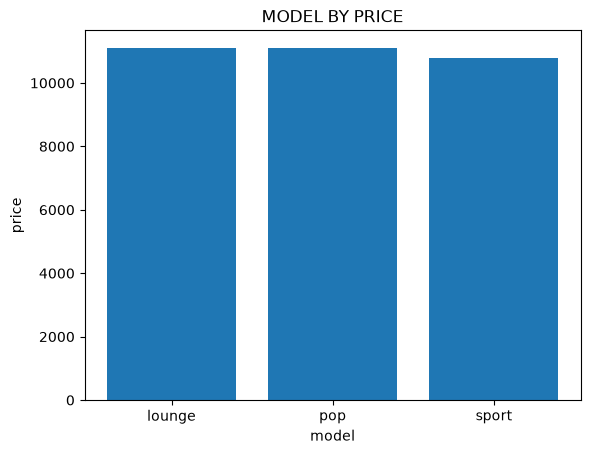

In [11]:
#matplotlib     (bar chart)
plt.bar(data1['model'],data1['price'])
plt.title("MODEL BY PRICE")
plt.xlabel('model')
plt.ylabel('price')
plt.show()

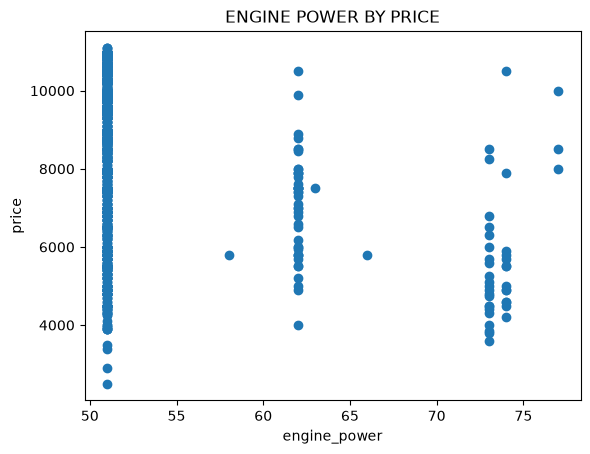

In [12]:
#matplotlib     scatter()
plt.scatter(data1['engine_power'],data1['price'])
plt.title("ENGINE POWER BY PRICE")
plt.xlabel('engine_power')
plt.ylabel('price')
plt.show()

In [13]:
#select x and y   (x=input,y=output)
x=data1[['engine_power']]
y=data1['price']

In [14]:
x

,engine_power
0,51
1,51
2,74
3,51
4,73
...,...
1515,51
1516,74
1517,51
1518,51


In [15]:
y

0       8900
1       8800
2       4200
3       6000
4       5700
        ... 
1515    5200
1516    4600
1517    7500
1518    5990
1519    7900
Name: price, Length: 1520, dtype: int64

In [16]:
#train /test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
#create model
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-135.11]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['engine_power']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.56e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [18]:
#prdict
y_pred=model.predict([[100]])
y_pred

array([2085.77113673])